In [35]:
import ast
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)
np.random.seed(42)

In [36]:
# ── Paths ────────────────────────────────────────────────
CSV_PATH = "..\\Datasets\\rtde_data.csv"
SAVE_DIR = "..\\Models\\test"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Data ─────────────────────────────────────────────────
SAMPLE_RATE      = 100
GAP_THRESHOLD    = 0.015
VELOCITY_EPSILON = 0.001

# ── MLP AE ───────────────────────────────────────────────
LATENT_DIM = 16
DROPOUT    = 0.2

# ── Training ─────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 1000
LEARNING_RATE = 1e-3

# ── Anomaly ──────────────────────────────────────────────
THRESHOLD_PERCENTILE = 99.9

# ── Split ────────────────────────────────────────────────
VAL_SIZE  = 0.10
TEST_SIZE = 0.10

In [37]:
df = pd.read_csv(CSV_PATH)

print(f"Shape    : {df.shape}")
print(f"Duration : {len(df) / SAMPLE_RATE:.1f} seconds")
print(f"Columns  : {list(df.columns)}")
df.head(3)

Shape    : (33486, 14)
Duration : 334.9 seconds
Columns  : ['timestamp', 'target_q', 'target_qd', 'target_qdd', 'target_current', 'target_moment', 'actual_q', 'actual_qd', 'actual_current', 'joint_temperatures', 'joint_mode', 'target_TCP_pose', 'actual_TCP_pose', 'robot_mode']


,timestamp,target_q,target_qd,target_qdd,target_current,target_moment,actual_q,actual_qd,actual_current,joint_temperatures,joint_mode,target_TCP_pose,actual_TCP_pose,robot_mode
0,265686.834,"[-0.20761281648727525, -1.9363509617246786, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.2126688723411795e-16, -0.7857670787312422, ...","[1.3855484745821294e-15, -8.988702786535187, -...","[-0.20763665834535772, -1.9363509617247523, 1....","[0.0, 0.0, -0.0, -0.0, 0.0, 0.0]","[0.23777902126312256, -0.9878473281860352, -1....","[26.375, 26.5, 26.75, 31.25, 34.125, 35.1875]","[253, 253, 253, 253, 253, 253]","[-0.3763243926971161, -0.05798771187024637, 0....","[-0.37632254996455616, -0.057974038383734536, ...",7
1,265686.842,"[-0.20761281648727525, -1.9363509617246786, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.180065856588544e-16, -0.7857197440113755, -...","[1.3482975318283752e-15, -8.98816130580905, -2...","[-0.2076485792743128, -1.9363271198668421, 1.9...","[0.0, 0.0, -0.0, -0.0, 0.0, 0.0]","[0.2560155987739563, -1.0181230306625366, -1.8...","[26.375, 26.5, 26.75, 31.25, 34.125, 35.1875]","[253, 253, 253, 253, 253, 253]","[-0.3763243926971161, -0.05798771187024637, 0....","[-0.37632962076385607, -0.05798160780578084, 0...",7
2,265686.850,"[-0.20761281648727525, -1.9363509617246786, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.017134512430945e-16, -0.785726478581895, -2...","[1.1621384899760469e-15, -8.988238345245335, -...","[-0.20761281648744756, -1.9363509617247523, 1....","[0.0, 0.0, -0.0, -0.0, 0.0, 0.0]","[0.2293904721736908, -1.0122623443603516, -1.8...","[26.375, 26.5, 26.75, 31.25, 34.125, 35.1875]","[253, 253, 253, 253, 253, 253]","[-0.3763243926971161, -0.05798771187024637, 0....","[-0.37632629669394063, -0.057981910944731596, ...",7


In [38]:
keep_cols = [
    'actual_current',      
    'target_current',      
    'joint_temperatures',  
    'target_moment',       
]

existing_keep = [c for c in keep_cols if c in df.columns]
df = df[existing_keep]

print(f"Kept columns : {list(df.columns)}")
print(f"Shape        : {df.shape}")

Kept columns : ['actual_current', 'target_current', 'joint_temperatures', 'target_moment']
Shape        : (33486, 4)


In [39]:
for col in df.columns:
    sample = df[col].iloc[0]
    if not isinstance(sample, str):
        print(f"[SKIP] '{col}' already parsed")
        continue

    parsed = df[col].apply(ast.literal_eval)
    n = len(parsed.iloc[0])
    expanded = pd.DataFrame(
        parsed.tolist(),
        columns=[f"{col}_{i}" for i in range(n)],
        index=df.index
    )
    df = pd.concat([df.drop(columns=[col]), expanded], axis=1)
    print(f"Expanded '{col}' → {n} columns")

print(f"\nShape after expansion: {df.shape}")
df.head(3)

Expanded 'actual_current' → 6 columns
Expanded 'target_current' → 6 columns
Expanded 'joint_temperatures' → 6 columns
Expanded 'target_moment' → 6 columns

Shape after expansion: (33486, 24)


,actual_current_0,actual_current_1,actual_current_2,actual_current_3,actual_current_4,actual_current_5,target_current_0,target_current_1,target_current_2,target_current_3,...,joint_temperatures_2,joint_temperatures_3,joint_temperatures_4,joint_temperatures_5,target_moment_0,target_moment_1,target_moment_2,target_moment_3,target_moment_4,target_moment_5
0,0.237779,-0.987847,-1.872177,-0.520921,0.050121,-0.303221,1.212669e-16,-0.785767,-2.191135,-0.378155,...,26.75,31.25,34.125,35.1875,1.385548e-15,-8.988703,-25.263701,-2.958802,0.011053,0.0
1,0.256016,-1.018123,-1.891300,-0.522808,0.067461,-0.294840,1.180066e-16,-0.785720,-2.191132,-0.378152,...,26.75,31.25,34.125,35.1875,1.348298e-15,-8.988161,-25.263667,-2.958778,0.011079,0.0
2,0.229390,-1.012262,-1.897665,-0.525495,0.053996,-0.295797,1.017135e-16,-0.785726,-2.191138,-0.378161,...,26.75,31.25,34.125,35.1875,1.162138e-15,-8.988238,-25.263744,-2.958850,0.011028,0.0


In [40]:
for i in range(6):
    df[f'track_err_I_{i}'] = df[f'actual_current_{i}'] - df[f'target_current_{i}']

target_cols = [f'target_current_{i}' for i in range(6)]
df.drop(columns=target_cols, inplace=True)

print(f"Shape : {df.shape}")
print(f"Features : {list(df.columns)}")

Shape : (33486, 24)
Features : ['actual_current_0', 'actual_current_1', 'actual_current_2', 'actual_current_3', 'actual_current_4', 'actual_current_5', 'joint_temperatures_0', 'joint_temperatures_1', 'joint_temperatures_2', 'joint_temperatures_3', 'joint_temperatures_4', 'joint_temperatures_5', 'target_moment_0', 'target_moment_1', 'target_moment_2', 'target_moment_3', 'target_moment_4', 'target_moment_5', 'track_err_I_0', 'track_err_I_1', 'track_err_I_2', 'track_err_I_3', 'track_err_I_4', 'track_err_I_5']


In [41]:
from sklearn.model_selection import train_test_split

X_temp, X_test = train_test_split(df, test_size=TEST_SIZE, shuffle=False)
X_train, X_val = train_test_split(X_temp, test_size=VAL_SIZE/(1-TEST_SIZE), shuffle=False)

print(f"Train : {len(X_train):,} rows")
print(f"Val   : {len(X_val):,} rows")
print(f"Test  : {len(X_test):,} rows")

Train : 26,788 rows
Val   : 3,349 rows
Test  : 3,349 rows


In [42]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.pkl'))

['..\\Models\\test\\scaler.pkl']

In [43]:
N_ANOMALIES = 10   

rng = np.random.default_rng(42)
anomaly_indices = rng.choice(len(X_test), size=N_ANOMALIES, replace=False)

X_test_anomaly = X_test.copy()
X_test_anomaly[anomaly_indices] += np.random.normal(0, 3, (N_ANOMALIES, X_test.shape[1]))

# Labels: 0 = normal, 1 = anomaly
y_test = np.zeros(len(X_test), dtype=int)
y_test[anomaly_indices] = 1

print(f"X_test       : {X_test_anomaly.shape}")
print(f"Normal rows  : {(y_test == 0).sum():,}")
print(f"Anomaly rows : {(y_test == 1).sum():,}")
print(f"Anomaly idx  : {sorted(anomaly_indices)}")

X_test       : (3349, 24)
Normal rows  : 3,339
Anomaly rows : 10
Anomaly idx  : [np.int64(287), np.int64(298), np.int64(315), np.int64(674), np.int64(1448), np.int64(1467), np.int64(2187), np.int64(2334), np.int64(2585), np.int64(2872)]


In [45]:
'''def AE(input_dim, latent_dim, dropout):
    inputs = layers.Input(shape=(input_dim,))
    
    # Encoder
    x = layers.Dense(128)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)
    
    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout)(x)
    
    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    encoded = layers.Dense(latent_dim, activation='linear')(x)  # ← linear, not relu

    # Decoder (mirrors encoder)
    x = layers.Dense(32, activation='relu')(encoded)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    decoded = layers.Dense(input_dim, activation='linear')(x)

    return Model(inputs, decoded, name='MLP_Autoencoder')'''

def AE(input_dim, latent_dim):  
    inputs = layers.Input(shape=(input_dim,))
    
    # Encoder
    x = layers.Dense(128)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)  
    
    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    
    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    
    encoded = layers.Dense(latent_dim, activation='linear')(x)

    x = layers.Dense(32)(encoded)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    
    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    
    decoded = layers.Dense(input_dim, activation='linear')(x)

    return Model(inputs, decoded, name='MLP_Autoencoder')

INPUT_DIM = X_train.shape[1]   # 24 features

model = AE(INPUT_DIM, LATENT_DIM)
model.summary()

Model: "MLP_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,928 (116.91 KB)

 Trainable params: 29,032 (113.41 KB)

 Non-trainable params: 896 (3.50 KB)

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR, 'best_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

In [47]:
history = model.fit(
    X_train, X_train,          
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, model_checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/1000
402/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3482
Epoch 1: val_loss improved from None to 0.10409, saving model to ..\Models\test\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1779 - val_loss: 0.1041 - learning_rate: 0.0010
Epoch 2/1000
408/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0824
Epoch 2: val_loss improved from 0.10409 to 0.07161, saving model to ..\Models\test\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0769 - val_loss: 0.0716 - learning_rate: 0.0010
Epoch 3/1000
410/419 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0641
Epoch 3: val_loss improved from 0.07161 to 0.05859, saving model to ..\Models\test\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0624 - val_loss: 0.0586 - learning_rate: 0.0010
Epoch 4/1000
406/419 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0562
Epoch 4: val_loss improved from 0.05859 to 0.05170, saving model to ..\Models\test\best_model.keras
419/419 ━━━━━━━━━━━━━━━━━━━━ 1

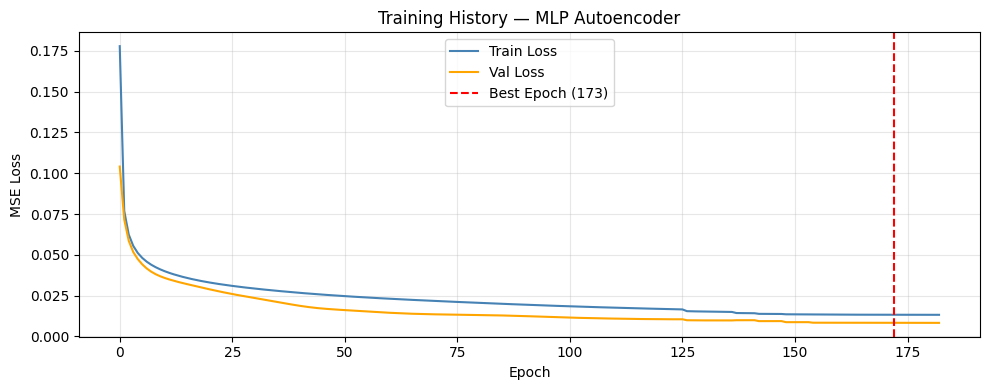

Best epoch     : 173
Best val_loss  : 0.0083


In [48]:
plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')

best_epoch = np.argmin(history.history['val_loss'])
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch + 1})')

plt.title('Training History — MLP Autoencoder')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best epoch     : {best_epoch + 1}")
print(f"Best val_loss  : {history.history['val_loss'][best_epoch]:.4f}")

In [49]:
train_preds = model.predict(X_train, verbose=0)
train_errors = np.mean(np.square(X_train - train_preds), axis=1)

threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

# ── Save ─────────────────────────────────────────────────
joblib.dump(threshold, os.path.join(SAVE_DIR, 'threshold.pkl'))

print(f"Train error — mean : {train_errors.mean():.4f}")
print(f"Train error — std  : {train_errors.std():.4f}")
print(f"Train error — max  : {train_errors.max():.4f}")
print(f"Threshold ({THRESHOLD_PERCENTILE}th percentile) : {threshold:.4f}")
print("Threshold saved ✓")

Train error — mean : 0.0029
Train error — std  : 0.0027
Train error — max  : 0.0668
Threshold (99.9th percentile) : 0.0235
Threshold saved ✓


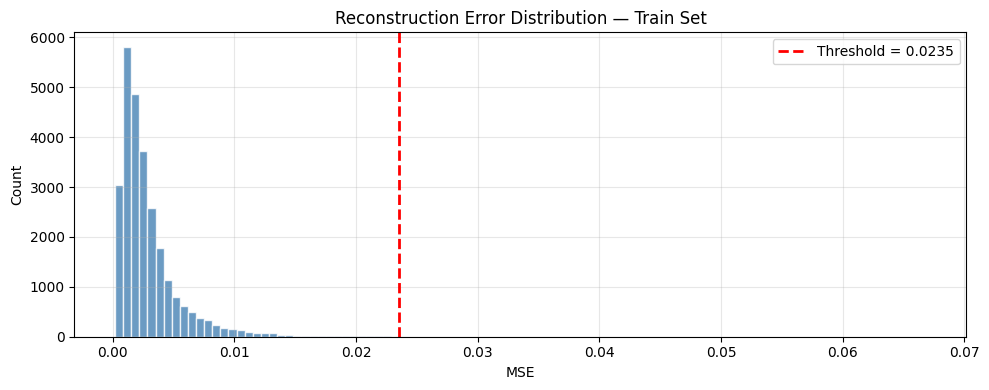

In [50]:
# ── Plot distribution ────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.title('Reconstruction Error Distribution — Train Set')
plt.xlabel('MSE')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
# ── حسب الـ reconstruction error على الـ test ────────────
test_preds  = model.predict(X_test_anomaly, verbose=0)
test_errors = np.mean(np.square(X_test_anomaly - test_preds), axis=1)

# ── Predict: فوق الـ threshold = anomaly ─────────────────
y_pred = (test_errors > threshold).astype(int)

print(f"Threshold         : {threshold:.4f}")
print(f"Normal detected   : {(y_pred == 0).sum():,}")
print(f"Anomaly detected  : {(y_pred == 1).sum():,}")

Threshold         : 0.0235
Normal detected   : 3,055
Anomaly detected  : 294



Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.96      3339
     Anomaly       0.03      1.00      0.07        10

    accuracy                           0.92      3349
   macro avg       0.52      0.96      0.51      3349
weighted avg       1.00      0.92      0.95      3349



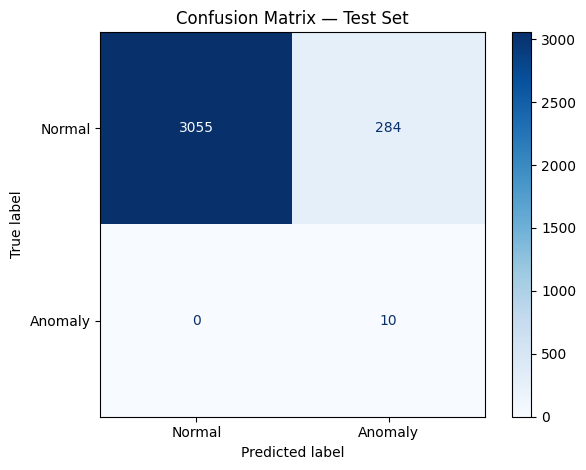

In [52]:
# ── Evaluation Metrics ───────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()